In [3]:
import numpy as np
import matplotlib.pyplot as plt

from froth import SnapData, ImageData, SnapConfig, ImageConfig, BubbleClassifier, BubbleExtractor
from froth.utils import cylindrical_boundary_mask
from froth import plots

<h2 style="font-family: Gill Sans; letter-spacing: 1px;"> Simulation Snapshot</h2>

In [4]:
# First-time setup: create a config file and edit the paths inside
# froth.create_default_config()  # uncomment to generate config.yaml

# Update 'snapshot_path' and output directories in config.yaml before proceeding
path_to_config = 'config.yaml'

In [5]:
# load snapshot 540 with temperature and time, restricting to |z| < 1.0 kpc
snap = SnapData(540, config_file = path_to_config, 
                load_options = {'temperature': True, 'time': True, 'z_limit': 1.0},)

In [19]:
# number of gas particles in this snapshot (after masking)
snap.num_particles

184640890

In [6]:
# view available 3D models
BubbleClassifier.list_models(display = True, model_type = '3d')

Name            Type Features                            Trained      Config              
------------------------------------------------------------------------------------------
aerate_3d       3D  ρ and T aware                       2026-02-13   aerate_3d.yaml      
aerate_3d_den   3D  ρ aware                             2026-02-13   aerate_3d_den_only.yaml
aerate_3d_hot   3D  ρ and T aware, hard negatives       2026-02-13   aerate_3d_hot.yaml  


{'aerate_3d': {'config': 'aerate_3d.yaml',
  'description': '3d model, ρ and T aware',
  'training_date': '2026-02-13'},
 'aerate_3d_den': {'config': 'aerate_3d_den_only.yaml',
  'description': '3d model, ρ aware',
  'training_date': '2026-02-13'},
 'aerate_3d_hot': {'config': 'aerate_3d_hot.yaml',
  'description': '3d model, ρ and T aware, hard negatives',
  'training_date': '2026-02-13'}}

In [10]:
# configure classification: 4 parallel jobs, use cached resul%notebooks if available
# set normalize=False if not working with a disk galaxy
snap_inner_config = SnapConfig(n_jobs = 4, force_recompute = False)

# initialise classifier
classifier = BubbleClassifier(model_name='aerate_3d', 
                              processing_config = snap_inner_config)

In [12]:
%%time
# run classifier — results stored in snap.labels
classifier.aerate_snapshot(snap, save_results = True)

-----> normalizing temperature with vertical profile ...
-----> loading snapshot 540...
   ✔   snapshot loaded
-----> creating vertical temperature profile ...
-----> creating temperature scaler ...
   ✔   temperature scaled.
-----> normalizing density with vertical profile ...
-----> creating vertical density profile ...
-----> creating density scaler ...
   ✔   density scaled.
◦ ○ ◎ ◉ ● aerating: 32 Voronoi chunks with 4 parallel jobs ... ● ◉ ◎ ○ ◦
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
-----> loading model aerate_3d ...
   ✔   model loaded
   ·   features: ['temperature', 'density']
   ·   device: cpu
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:  1.0min
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:  1.6min
[Parallel(n_jobs=4)]: Done  17 tasks      | elapsed:  2.7min
[Parallel(n_jobs=4)]: Done  24 tasks      | elapsed:  3.7min
[Parallel(n_jobs=4)]: Done  29 out of  32 | elapsed:  4.4min remaining:   27.0s
[Parallel(n_jobs=4)]: D

CPU times: user 1h 41min 5s, sys: 26min 45s, total: 2h 7min 51s
Wall time: 7min 41s


In [13]:
# mask to a cylindrical region of interest for open fraction calculations
boundary_mask = cylindrical_boundary_mask(snap.pos_R, snap.pos[:, 2], 
                                          R_limits=[7.5, 9.5], z_lims=[-1., 1.])

# extract and group bubbles; adjust peel_iteration, chunk_size and other parameters to your system
extractor = BubbleExtractor(snap, force_recompute=False, 
                            boundary_mask = boundary_mask,
                            skip_shell = False, 
                            inner_params = {'peel_iteration': 5, 'chunk_size': 2_000_000}, 
                            shell_params = {'pair_order': 'density'})

In [14]:
%%timnum_particles run extraction  — results stored in snap.bubble_groups
extractor.knock_snapshot()

(((●))) knocking (((●)))
-----> building adjacency matrix... 
-----> loading 32 Voronoi chunks ...
   ✔   Voronoi ridges loaded in 475.0s.
   ✔   adjacency matrix built.
-----> extracting k-core components (5 peeling iterations) ...
   ◈   iter 0 | min_size: 5 | scanned: 48763303 | components: 1423
   ◈   iter 1 | min_size: 5 | scanned: 41650410 | components: 1139
   ◈   iter 2 | min_size: 5 | scanned: 36155508 | components: 737
   ◈   iter 3 | min_size: 5 | scanned: 31693931 | components: 489
   ◈   iter 4 | min_size: 5 | scanned: 27909178 | components: 323
   ✔   done in 805.0s
-----> re-growing 3110 components ...
   ◈   iter 4 | t: 41.7s | assigned: 28534278
   ◈   iter 3 | t: 29.6s | assigned: 32146903
   ◈   iter 2 | t: 39.6s | assigned: 36444526
   ◈   iter 1 | t: 48.0s | assigned: 41745950
   ◈   iter 0 | t: 66.8s | assigned: 48702774
   ✔   done 
-----> merging ...
   ·   1843 candidate groups ...
   ◈   iter 0 | t: 216.1s | groups: 3110 → 1707
   ·   409 candidate groups ...


CPU times: user 51min 7s, sys: 5min 36s, total: 56min 44s
Wall time: 25min 12s


<h3 style="font-family: Gill Sans; letter-spacing: 1px;"> Results</h3>

In [15]:
# mask to a thin slice for visualisation
mask_z = plots.mask_pos_slice(snap.pos[:, 2], 0, thickness = 0.01)
mask_phi = plots.mask_pos_range(snap.pos_phi, 0, 0.125*np.pi)
mask_plot = mask_z & mask_phi

mask_bg = snap.bubble_groups == -1
mask_shell = (~snap.labels) & (~mask_bg)

# bubble_groups: integer group ID per particle, NaN for background
bubble_groups = snap.bubble_groups.copy().astype(float)
bubble_groups[bubble_groups == -1] = np.nan

# classify regions: 0 = background, 1 = inner bubble, 2 = shell
mask_bubble = np.full(snap.labels.size, 0)
mask_bubble[snap.labels] = 1
mask_bubble[mask_shell] = 2

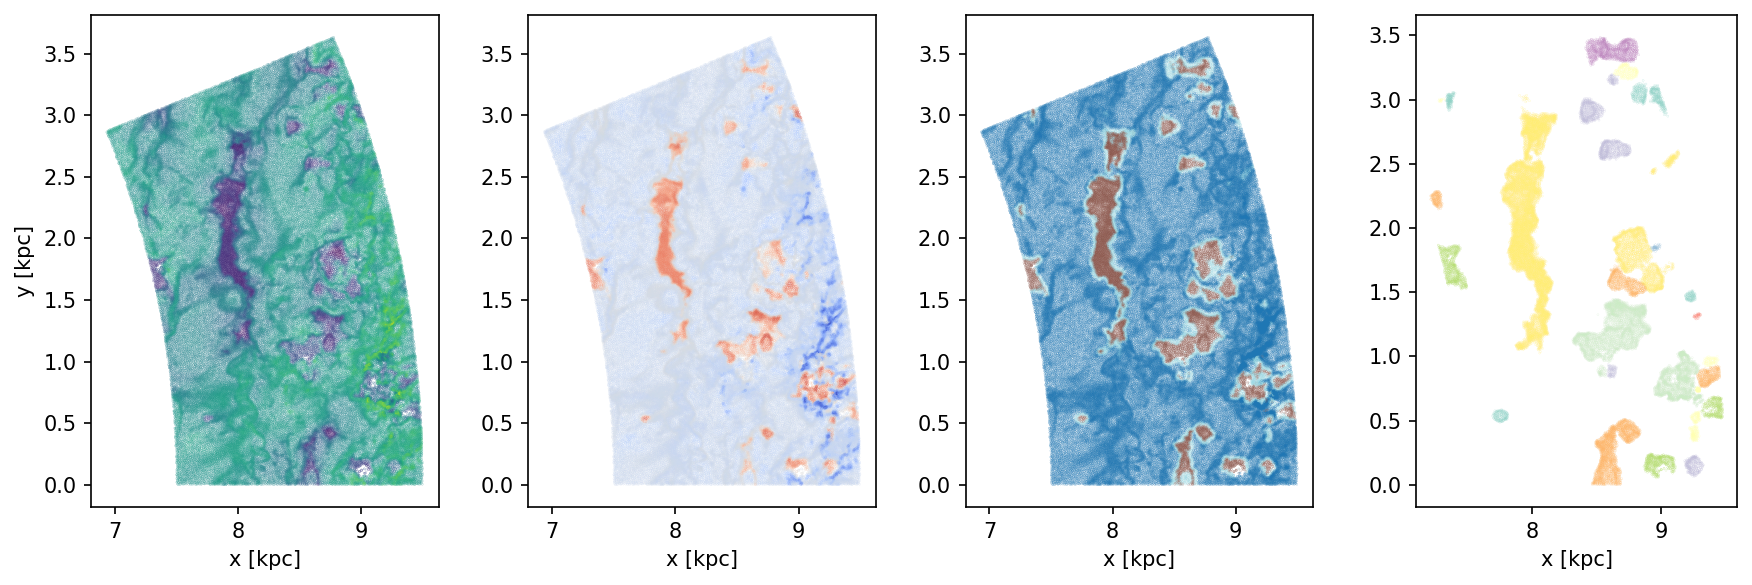

In [16]:
# panels: log density | log temperature | inner/shell mask | bubble group IDs
fig, ax = plots.plot_gas_scatter_2d(snap.pos[mask_plot], 
                  [np.log10(snap.den[mask_plot]), np.log10(snap.tem[mask_plot]), 
                   mask_bubble[mask_plot], bubble_groups[mask_plot]],
                            cmaps = ['viridis', 'coolwarm', 'tab20', 'Set3'],
                  plot_axes = [0, 1], figsize =(12, 4))

In [17]:
# extract particles along a 1D line through (x=8.6, z=0)
mask_line = plots.mask_line(snap.pos, x_pos=8.6, z_pos=0)

(<Figure size 900x600 with 4 Axes>,
 array([<Axes: xlabel='Y [kpc]', ylabel='$\\log$ $\\rho$ [g/cm$^{3}$]'>,
        <Axes: xlabel='Y [kpc]', ylabel='$\\log$ T [K]'>], dtype=object))

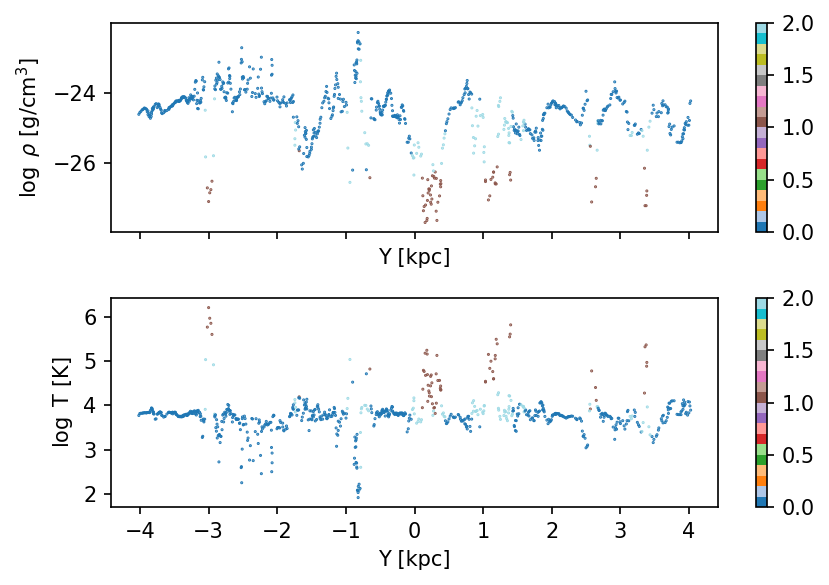

In [18]:
# line profiles of density and temperature, colored by region (inner/shell/background)
plots.plot_gas_line_profiles(snap.pos, axis=['y', 'y'], masks = [mask_line, mask_line], 
                             quantities = [np.log10(snap.den), np.log10(snap.tem)], 
                             color_quantities=[mask_bubble, mask_bubble],
                             cmaps=['tab20', 'tab20'],
                             ylabel = [r'$\log$ $\rho$ [g/cm$^{3}$]', '$\log$ T [K]'], 
                             marker_size = 0.2, plot_w_size = 6, plot_h_size = 2)

<h2 style="font-family: Gill Sans; letter-spacing: 1px;"> Galaxy Image </h2>

In [10]:
# load image
image = ImageData('./ngc0628_F770W_starsub_anchored.fits')

In [11]:
# configure classifier — currently only 'aerate_2d_den' is available for observational images
img_config = ImageConfig(save_scaler = False, 
                         batch_size = 2000000, 
                         smoothing_window = 30, 
                         stats_sigma = 5,
                         rotate = True)
classifier = BubbleClassifier('aerate_2d_den', processing_config = img_config)

In [13]:
# preprocess only — inspect result before full classification
classifier.aerate_image(image, preprocess_only=True)

-----> prep-rocessing image ...
   ✔   preprocessing done.


CPU times: user 4.33 s, sys: 442 ms, total: 4.77 s
Wall time: 13.6 s


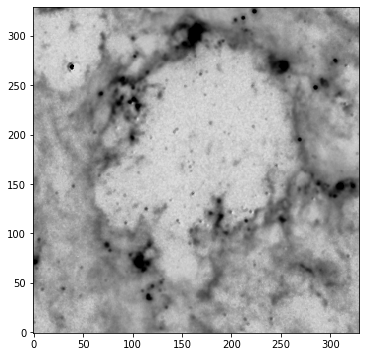

In [14]:
# inspect preprocessed image in a subregion before full classification
region = np.s_[370: 700, 160: 490]
plt.figure(figsize=(6, 6))
plt.imshow(np.arcsinh(image.data[region]), origin = 'lower', cmap='Greys', vmin = -0.8, vmax = 2.6, interpolation = 'none')

In [7]:
# run full classification
classifier.aerate_image(image)

-----> prep-rocessing image ...
   ✔   preprocessing done.
◦ ○ ◎ ◉ ● aerating with a batch size of 2000000 ... ● ◉ ◎ ○ ◦
-----> loading all pixel neighborhood information...
   ✔    done
/home/hpc/a104bc/a104bc20/py_env/lib/python3.9/site-packages/torch_geometric/sampler/neighbor_sampler.py:61: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  warnings.warn(f"Using '{self.__class__.__name__}' without a "
-----> loading model aerate_2d_den ...
   ✔   model loaded
   ·   features: ['column density']
   ·   device: cpu
●  ●  ● aerated ●  ●  ● 


In [8]:
# extract and group bubbles from classified image
extracter = BubbleExtractor(image, 
                            inner_params = {'peel_iteration': 10, 
                                            'min_component_size': 1, 
                                            'threshold': 0.5, 
                                             'chunk_size': 50000000, 
                                             'n_jobs': 1})

In [9]:
%%time
# run extraction
extracter.knock_image()

(((●))) knocking (((●)))
-----> extracting k-core components (10 peeling iterations) ...
   ◈   iter 0 | min_size: 1 | components: 1537
   ◈   iter 1 | min_size: 1 | components: 1436
   ◈   iter 2 | min_size: 1 | components: 1002
   ◈   iter 3 | min_size: 1 | components: 745
   ◈   iter 4 | min_size: 1 | components: 567
   ◈   iter 5 | min_size: 1 | components: 460
   ◈   iter 6 | min_size: 1 | components: 365
   ◈   iter 7 | min_size: 1 | components: 294
   ◈   iter 8 | min_size: 1 | components: 257
   ◈   iter 9 | min_size: 1 | components: 212
   ✔   done in 8.0s
-----> re-growing 3134 components ...
-----> loading all neighborhood information...
   ✔    done
   ◈   iter 9 | t: 1.6s | assigned: 518651
   ◈   iter 8 | t: 2.2s | assigned: 524410
   ◈   iter 7 | t: 0.1s | assigned: 539545
   ◈   iter 6 | t: 0.3s | assigned: 560826
   ◈   iter 5 | t: 0.2s | assigned: 590134
   ◈   iter 4 | t: 0.4s | assigned: 631461
   ◈   iter 3 | t: 0.3s | assigned: 684254
   ◈   iter 2 | t: 0.6s | ass

CPU times: user 4min 2s, sys: 1.66 s, total: 4min 4s
Wall time: 39 s


<h3 style="font-family: Gill Sans; letter-spacing: 1px;"> Results</h3>

In [10]:
# prepare group labels for visualisation
inner_groups = image.inner_assigned.reshape(image.data.shape).astype(float)
inner_groups[inner_groups == -1] = np.nan

bubble_groups = image.bubble_groups.astype(float)
bubble_groups[bubble_groups == -1] = np.nan

# shuffle colormap labels for visual contrast between adjacent groups
def shuffle_labels(markers):
    labels = np.unique(markers)
    np.random.shuffle(labels)
    print(len(labels))
    markers_new = markers.copy()
    for ind in range(len(labels)):
        if labels[ind] == 0:
            continue
        markers_new[markers == labels[ind]] = ind + 1
    return markers_new

106


Text(0, 0.5, 'Image Y [pixel]')

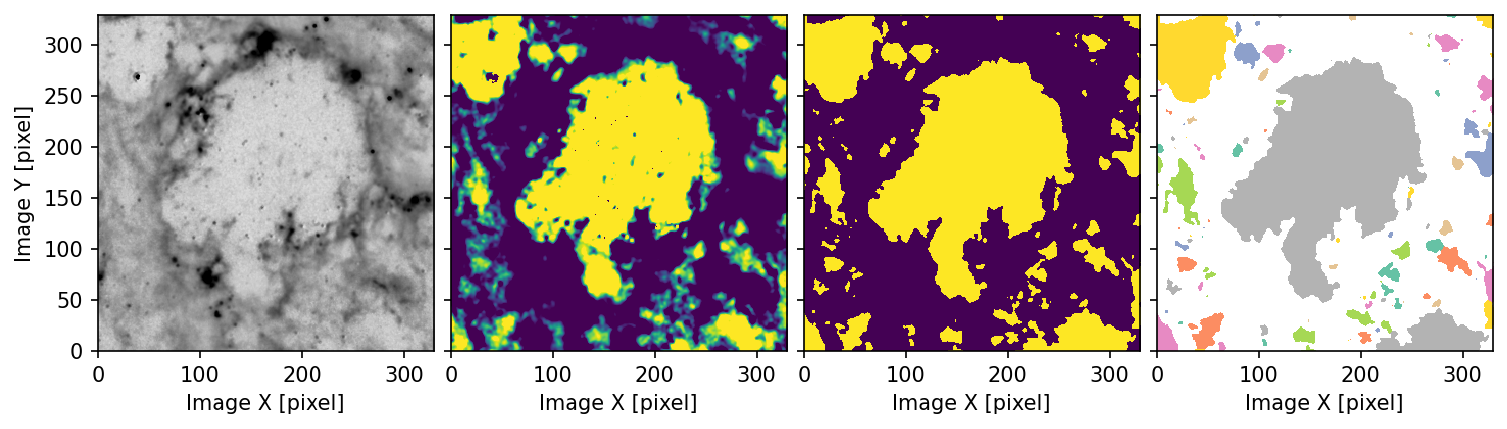

In [12]:
# plot: raw image | classification probability | inner mask | bubble groups
region = np.s_[370: 700, 160: 490]

fig, ax = plt.subplots(1, 4, figsize=(12, 4), dpi = 150, sharex = True, sharey = True)
plt.subplots_adjust(wspace = 0.05)

ax[0].imshow(np.arcsinh(image.data[region]), origin = 'lower', 
             cmap='Greys', vmin = -0.8, vmax = 2.6, interpolation = 'none')
ax[1].imshow(image.probs[region], vmin = 0.2, vmax = 0.8, origin='lower', 
             interpolation = 'none')
ax[2].imshow(image.inner[region], origin='lower', interpolation = 'none')
ax[3].imshow(shuffle_labels(inner_groups[region]), origin = 'lower', cmap='Set2',
             interpolation = 'none')
for ax_i in ax:
    ax_i.set_xlabel('Image X [pixel]')
ax[0].set_ylabel('Image Y [pixel]')